# FScanpy Prediction Results Interpretation

[![中文](https://img.shields.io/badge/Language-中文-red.svg)](predict_sample_zh.ipynb)

This notebook provides detailed interpretation of FScanpy prediction results, explaining output fields and how to analyze predictions.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Import FScanpy related modules
from FScanpy import PRFPredictor, predict_prf, plot_prf_prediction
from FScanpy.data import get_test_data_path, list_test_data
from FScanpy.utils import fscanr, extract_prf_regions

2025-08-14 15:56:50.631778: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-14 15:56:50.632231: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-14 15:56:50.684833: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/guest01/.conda/envs/fs/lib/python3.9/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core

In [2]:
data = pd.read_excel(get_test_data_path('full_seq.xlsx'))
print(data.head())

   Position Codon                               33bp  \
0       114   GCC  TCTGGAAGAAGTAAACGCCGAGCTGGAACAGCC   
1      1794   CCC  GGGGCAGTCCCCTAGCCCCGCTCAAAAGGGGGA   
2       234   GTC  CCACAAGTCTCGTTTCGTCGATCTTCTGGAGTT   
3       129   TCC  GGCTGCGGTTGCAAACTCCGAAGTCGATGCACT   
4       216   GAC  GGAGCAGCGGGTAAATGACCTCTTGGAGCTGTT   

                                               399bp  Sequence_ID  \
0  NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...            0   
1  GACAGGACACATCAGAAAAGACTGTAAGGATGAAAAGGGCTCAAAA...            1   
2  CAATTCCAATTCCATGTCGATGATCGGTCAAAGCCCCCCGTGCTGC...            5   
3  NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...           12   
4  TGAACTTAAGAGCCGCATTCTTTCCGATATGGTGCGACTTGACATT...           14   

                                       Full_Sequence  
0  ATGTTTGAAATTAACCCGGTGAATAACCGCATTCAGGACCTCACGG...  
1  ATGGGGGTCTCGGGATCAAAAGGGCAGAAACTCTTTGTTTCTGTTC...  
2  ATGTCGAGTAGTATCGTCCTCAGTAATAATAATTCCAATTCCAATT...  
3  ATGAACAAAGAAAATGTCATTACCC

/mnt/lmpbe/guest01/FScanpy-package-main/FScanpy/predictor.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/guest01/.conda/envs/fs/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/guest01/.conda/envs/fs/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier from version 1.6.0 when using version 1.6.1. This might lead to breaking co

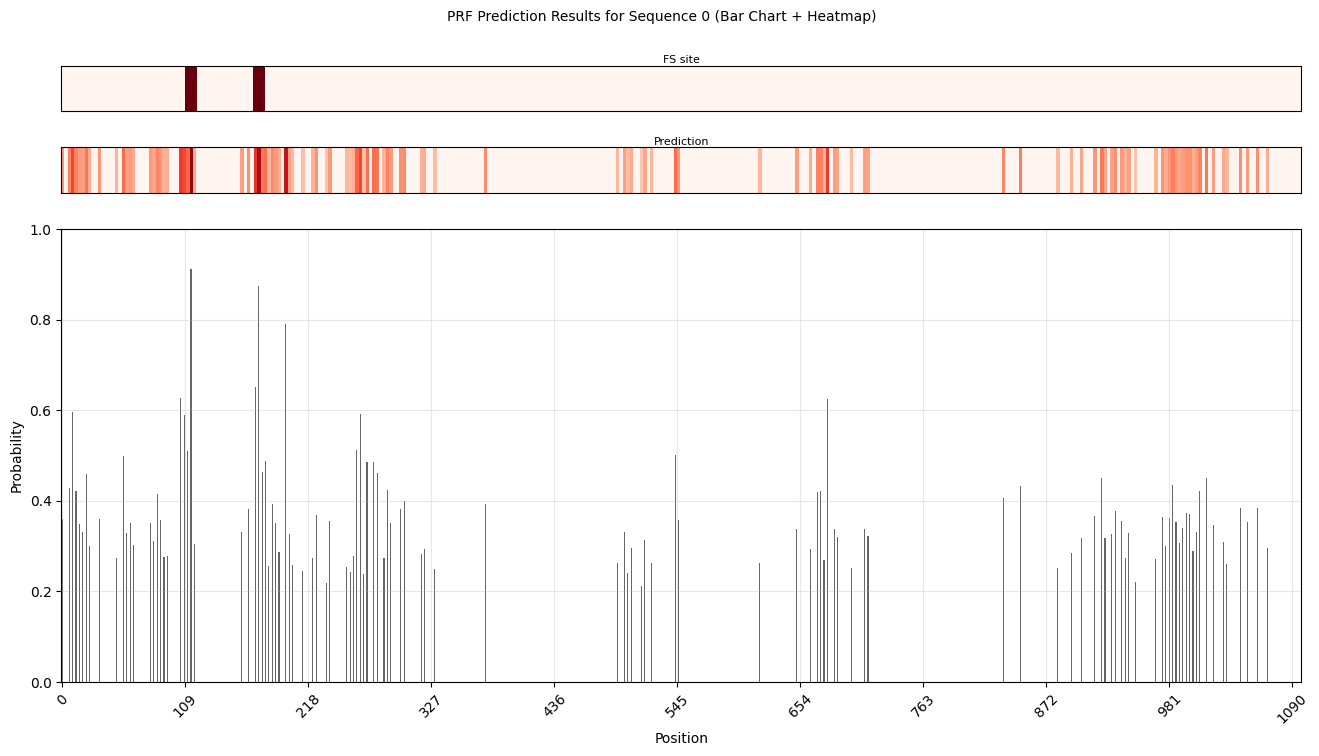

In [3]:
sequence_results0, fig0 = plot_prf_prediction(
    sequence=str(data.iloc[0]['Full_Sequence']),
    window_size=3,
    short_threshold=0.2,
    long_threshold=0.2,
    ensemble_weight=0.6,
    title=f"PRF Prediction Results for Sequence {data.iloc[0]['Sequence_ID']} (Bar Chart + Heatmap)",
    figsize=(16, 8),
    dpi=150
)

## Sequence0: High-Confidence, Unambiguous Signal
- Known Ground Truth: The programmed ribosomal frameshifting (PRF) event for this sequence occurs at nucleotide 113.

- Plot Interpretation: The FScanpy analysis shows a prominent probability peak at the 113 nt position. The magnitude of this peak significantly exceeds other regions in the sequence, and the surrounding bases also exhibit elevated frameshifting probabilities, forming a concentrated and well-defined signal. This indicates a high-confidence prediction from the model that corresponds precisely with the known PRF event location.

c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
a:\Code\fscanpy-package\FScanpy\predictor.py:347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


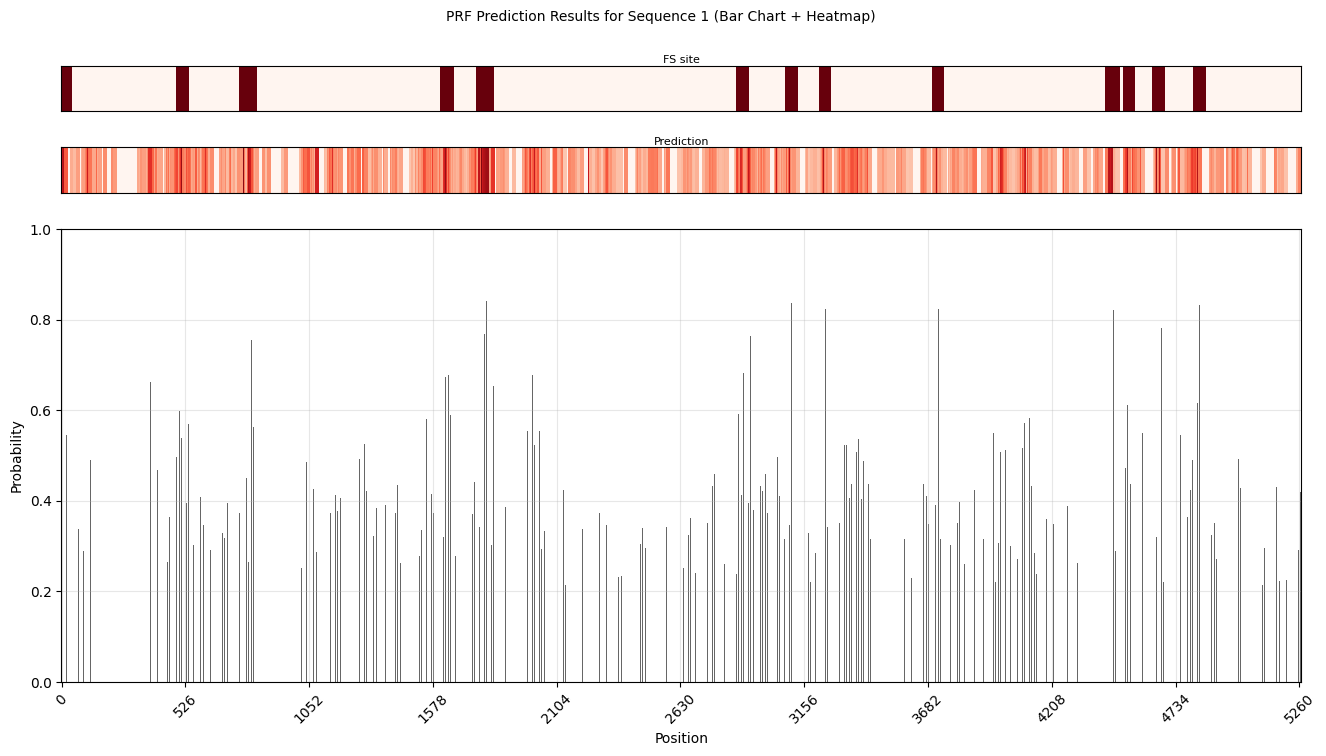

In [4]:
sequence_results1, fig1 = plot_prf_prediction(
    sequence=str(data.iloc[1]['Full_Sequence']),
    window_size=3,
    short_threshold=0.2,
    long_threshold=0.2,
    ensemble_weight=0.6,
    title=f"PRF Prediction Results for Sequence {data.iloc[1]['Sequence_ID']} (Bar Chart + Heatmap)",
    figsize=(16, 8),
    dpi=150
)

## Sequence1: Ambiguous Signal at Low Resolution
- Known Ground Truth: The PRF event for this sequence occurs at nucleotide 1794.

- Plot Interpretation: An initial low-resolution scan of Sequence1 identifies a probability peak near the known 1794 nt site. However, the plot also reveals multiple potential signal peaks of comparable intensity elsewhere, making it difficult to definitively identify the true event from this view alone. To resolve this ambiguity, a high-resolution analysis is necessary. By reducing the `window_size` parameter, the analysis can focus on the local vicinity of each peak to assess the concentration of high-probability predictions, which helps distinguish a true signal from background noise.

c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
a:\Code\fscanpy-package\FScanpy\predictor.py:347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


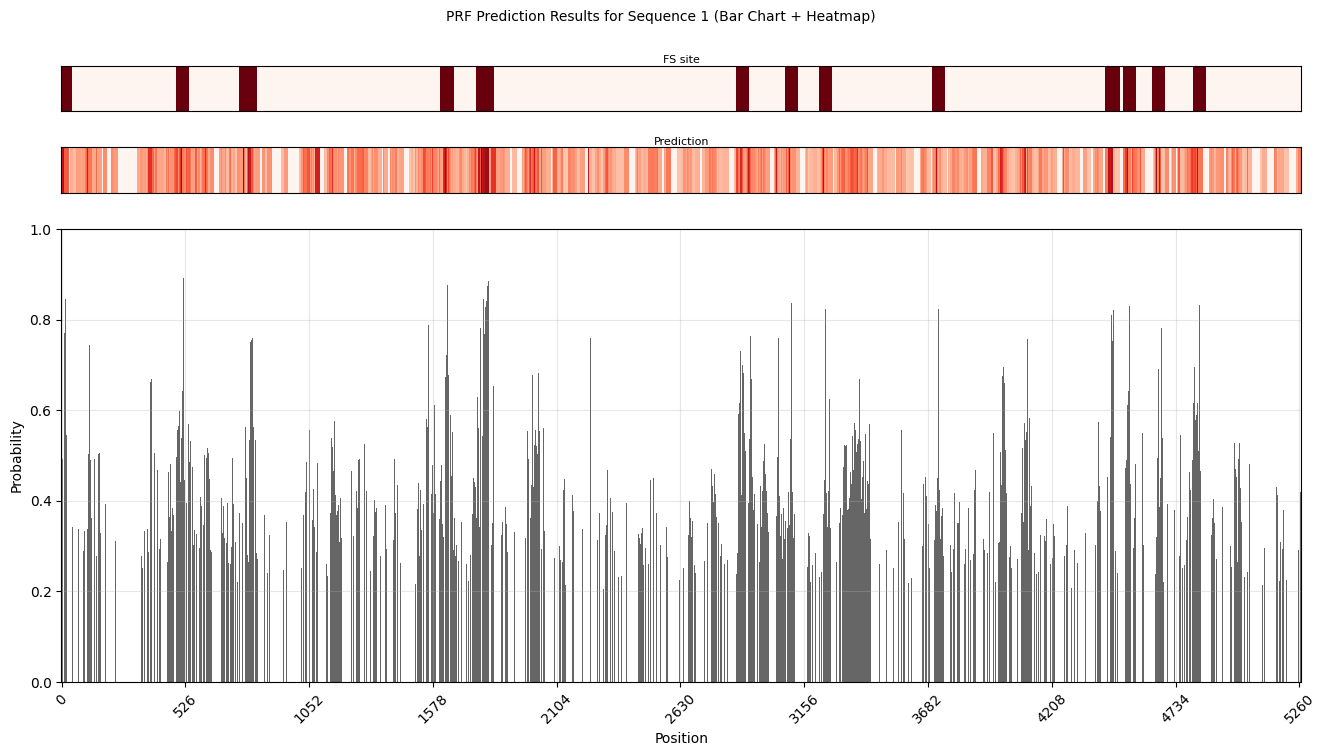

In [5]:
sequence_results1, fig1 = plot_prf_prediction(
    sequence=str(data.iloc[1]['Full_Sequence']),
    window_size=1,
    short_threshold=0.2,
    long_threshold=0.2,
    ensemble_weight=0.6,
    title=f"PRF Prediction Results for Sequence {data.iloc[1]['Sequence_ID']} (Bar Chart + Heatmap)",
    figsize=(16, 8),
    dpi=150
)

## Sequence1: Signal Confirmation at High Resolution
- Known Ground Truth: The PRF event for this sequence occurs at nucleotide 1794.

- Plot Interpretation: Following the high-resolution analysis, the results clearly show a dense cluster of high-probability bases centered around the 1794 nt position. In contrast, the other peaks identified in the initial scan do not show a similar concentration and appear as isolated, singular data points. This consolidation of the signal confirms that the 1794 nt site is the more reliable PRF event, with a much higher likelihood than other potential sites in the sequence.

c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
a:\Code\fscanpy-package\FScanpy\predictor.py:347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


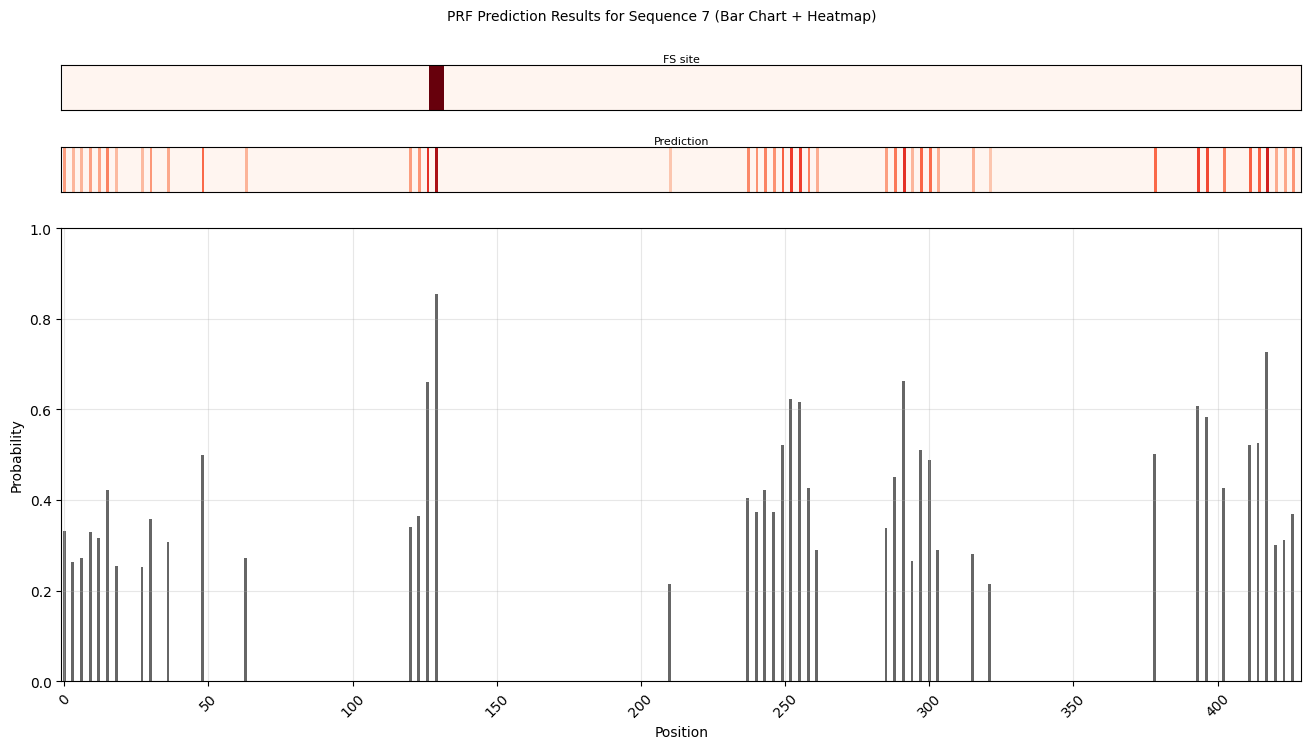

In [9]:
sequence_results2, fig2 = plot_prf_prediction(
    sequence=str(data.iloc[2]['Full_Sequence']),
    window_size=3,
    short_threshold=0.2,
    long_threshold=0.2,
    ensemble_weight=0.6,
    title=f"PRF Prediction Results for Sequence {data.iloc[12]['Sequence_ID']} (Bar Chart + Heatmap)",
    figsize=(16, 8),
    dpi=150
)

c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
a:\Code\fscanpy-package\FScanpy\predictor.py:347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


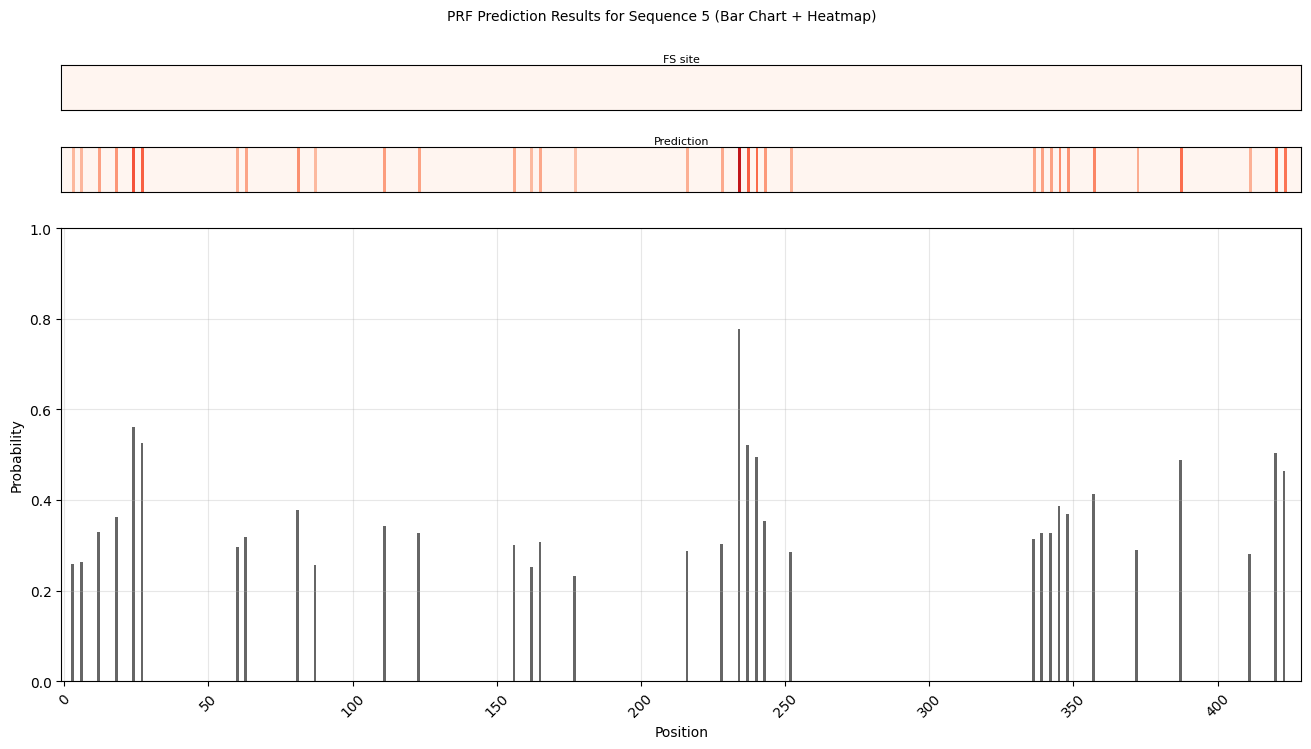

In [ ]:
sequence_results0, fig0 = plot_prf_prediction(
    sequence=str(data.iloc[3]['Full_Sequence']),
    window_size=3,
    short_threshold=0.2,
    long_threshold=0.2,
    ensemble_weight=0.6,
    title=f"PRF Prediction Results for Sequence {data.iloc[3]['Sequence_ID']} (Bar Chart + Heatmap)",
    figsize=(16, 8),
    dpi=150
)

c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\31598\.conda\envs\fs\lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingClassifier from version 1.6.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
a:\Code\fscanpy-package\FScanpy\predictor.py:347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


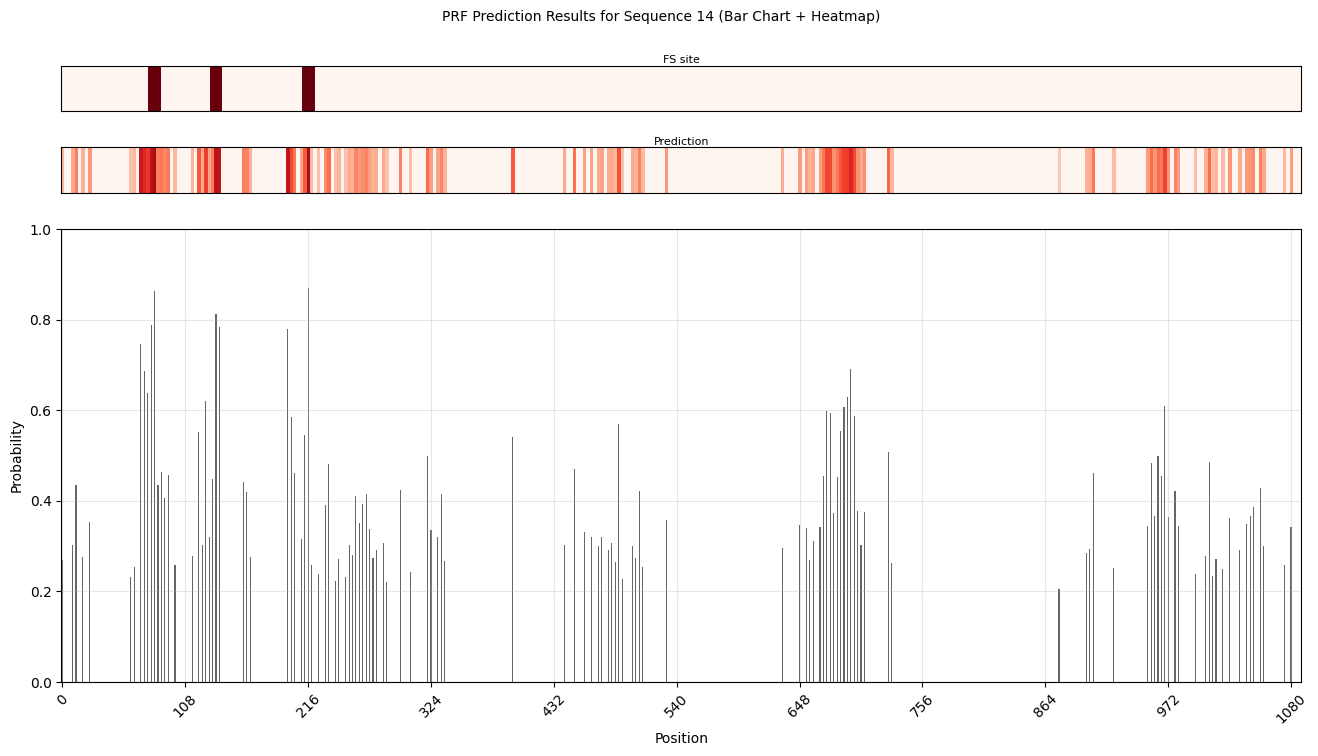

In [ ]:
sequence_results4, fig4 = plot_prf_prediction(
    sequence=str(data.iloc[4]['Full_Sequence']),
    window_size=3,
    short_threshold=0.2,
    long_threshold=0.2,
    ensemble_weight=0.4,
    title=f"PRF Prediction Results for Sequence {data.iloc[4]['Sequence_ID']} (Bar Chart + Heatmap)",
    figsize=(16, 8),
    dpi=150
)

## Sequence4: Ambiguous Result Requiring Experimental Validation
- Known Ground Truth: The PRF event for this sequence occurs at nucleotide 216.

- Plot Interpretation: This analysis demonstrates the inherent limitations of computational methods. FScanpy identifies three significant probability peaks, with the peaks at ~80 nt and the true site at 216 nt showing no decisive difference in magnitude. In such cases, the computational result alone is insufficient to distinguish the true PRF event. The model successfully narrows down the potential candidates to a few key regions, but subsequent biological (wet-lab) experiments are essential to validate which site is functionally active.